In [1]:
import os
import sys
import yaml
import copy
import numpy as np
import pandas as pd
import xarray as xr

In [2]:
import cmaps
# graph tools
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
import matplotlib.colorbar as cbar
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cartopy.crs as ccrs
import cartopy.mpl.geoaxes
import cartopy.feature as cfeature

%matplotlib inline

In [3]:
sys.path.insert(0, os.path.realpath('../libs/'))
import graph_utils as gu
#import verif_utils as vu

In [4]:
fig_keys = {
    'dpi': 150, 
    'orientation':'portrait', 
    'bbox_inches':'tight', 
    'pad_inches':0.1, 
    'transparent':False
}

need_publish = True

if need_publish:
    dpi_ = fig_keys['dpi']
else:
    dpi_ = 75

In [5]:
# def lon_to_0360(lon):
#     return lon % 360.0

# def subset_stn(ds_ACC_all: xr.Dataset, key: str, method: str = "nearest") -> xr.DataArray:
#     sites = list(dict_loc.keys())
#     lats = xr.DataArray([dict_loc[s][0] for s in sites], dims="site", coords={"site": sites})
#     lons = xr.DataArray([lon_to_0360(dict_loc[s][1]) for s in sites], dims="site", coords={"site": sites})

#     # result dims: (site, lead_year)
#     return ds_ACC_all[key].sel(lat=lats, lon=lons, method=method)


In [6]:
scale_param = '110m'

PROVINCE = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale=scale_param,
    facecolor='none')

def map_gridline_opt(ax):
    '''
    Customize cartopy map gridlines
    '''
    # ax.add_feature(cfeature.BORDERS.with_scale(scale_param), linestyle='-', linewidth=0.5, zorder=7)
    # ax.add_feature(PROVINCE, edgecolor='k', linestyle='-', linewidth=0.5, zorder=7)
    ax.add_feature(cfeature.COASTLINE.with_scale(scale_param ), edgecolor='k', linewidth=1.0, zorder=5)
    ax.spines['geo'].set_linewidth(2.5)
    return ax

In [7]:
def compute_regional_means(da, weights):
    """
    Compute area-weighted means over four regions, returning a Dataset
    with dim (lead_year,) and a 'region' coord.
    """
    regions = {
        'Global':  dict(lat=slice(-90, 90)),
        'Tropics': dict(lat=slice(-30, 30)),
        'NH ET':   dict(lat=slice(30, 90)),
        'SH ET':   dict(lat=slice(-90, -30)),
    }

    out = {}
    for name, sel in regions.items():
        da_region = da.sel(**sel)
        w_region = weights.sel(**sel)
        out[name] = da_region.weighted(w_region).mean(['lat', 'lon'])

    return xr.concat(list(out.values()), dim='region').assign_coords(
        region=list(regions.keys())
    )


def prepare_plot_data(ds_skill, var_list, leads_to_show):
    """
    Slice maps at selected leads and compute regional-mean curves.
    Returns a Dataset with everything needed for plotting.
    """
    weights = np.cos(np.deg2rad(ds_skill.lat))

    maps = {}
    curves = {}

    for varname in var_list:
        da = ds_skill[varname]                              # (lead, lat, lon)
        maps[varname]   = da.sel(lead_year=leads_to_show)   # (4, lat, lon)
        curves[varname] = compute_regional_means(da, weights)  # (region, lead)

    ds_maps   = xr.Dataset(maps)
    ds_curves = xr.Dataset(curves)

    # Force computation now so plotting is instant
    ds_maps   = ds_maps.compute()
    ds_curves = ds_curves.compute()

    return ds_maps, ds_curves


def get_color_limits(ds_maps, var_list, q_low=0.02, q_high=0.98):
    """
    Auto-determine vmin/vmax from the 2nd/98th percentile of each variable's
    map data across all selected leads. Override for ACC to use symmetric range.
    """
    limits = {}
    for varname in var_list:
        metric = varname.split('_')[2]
        da = ds_maps[varname]

        if metric == 'ACC':
            vmax = float(np.abs(da).quantile(q_high))
            limits[varname] = {'vmin': -vmax, 'vmax': vmax}
        else:
            limits[varname] = {
                'vmin': float(da.quantile(q_low)),
                'vmax': float(da.quantile(q_high)),
            }
    return limits

### Data

In [8]:
ds_skill = xr.open_zarr('/glade/derecho/scratch/ksha/EPRI_data/METRICS_GLOBE/SMYLE_Verif.zarr')
ds_skill = ds_skill.load()

In [9]:
ds_skill

<xarray.Dataset> Size: 106MB
Dimensions:                     (lead_year: 10, lat: 192, lon: 288)
Coordinates:
  * lat                         (lat) float64 2kB -90.0 -89.06 ... 89.06 90.0
  * lead_year                   (lead_year) int64 80B 0 1 2 3 4 5 6 7 8 9
  * lon                         (lon) float64 2kB 0.0 1.25 2.5 ... 357.5 358.8
Data variables: (12/32)
    PRECT_max_ACC_detrend       (lead_year, lat, lon) float64 4MB 0.1346 ... ...
    PRECT_max_ACC_raw           (lead_year, lat, lon) float32 2MB 0.256 ... -...
    PRECT_max_CRPSS_detrend     (lead_year, lat, lon) float64 4MB -4.882 ... ...
    PRECT_max_CRPSS_raw         (lead_year, lat, lon) float32 2MB -0.4543 ......
    PRECT_max_CRPS_detrend      (lead_year, lat, lon) float64 4MB 1.754 ... 4...
    PRECT_max_CRPS_raw          (lead_year, lat, lon) float32 2MB 0.4844 ... ...
    ...                          ...
    TREFHT_mean_CRPSS_detrend   (lead_year, lat, lon) float64 4MB 0.03272 ......
    TREFHT_mean_CRPSS_raw       (lead_year, lat, lon) float32 2MB -9.868 ... ...
    TREFHT_mean_CRPS_detrend    (lead_year, lat, lon) float64 4MB 0.4242 ... ...
    TREFHT_mean_CRPS_raw        (lead_year, lat, lon) float32 2MB 4.819 ... 2...
    TREFHT_mean_RMSE_detrend    (lead_year, lat, lon) float64 4MB 0.745 ... 0...
    TREFHT_mean_RMSE_raw        (lead_year, lat, lon) float32 2MB 5.177 ... 2...

In [10]:
leads_plot = [0, 4, 9]

## Plot

In [11]:
x = ds_skill['lon'].values
y = ds_skill['lat'].values
lon, lat = np.meshgrid(x, y)

# cmap_all = gu.precip_cmap(return_rgb=False, land_map=False)
# cmap = gu.precip_cmap(return_rgb=False, land_map=False)

my_colors = gu.ksha_color_set_summon(color_set=0)
cyan = np.array([0.4, 0.8, 1, 1])
blue = my_colors['blue']
red = my_colors['red']
orange = my_colors['orange']

### Annual Mean 2-m Temp

In [12]:
cmap_all = cmaps.prcp_2

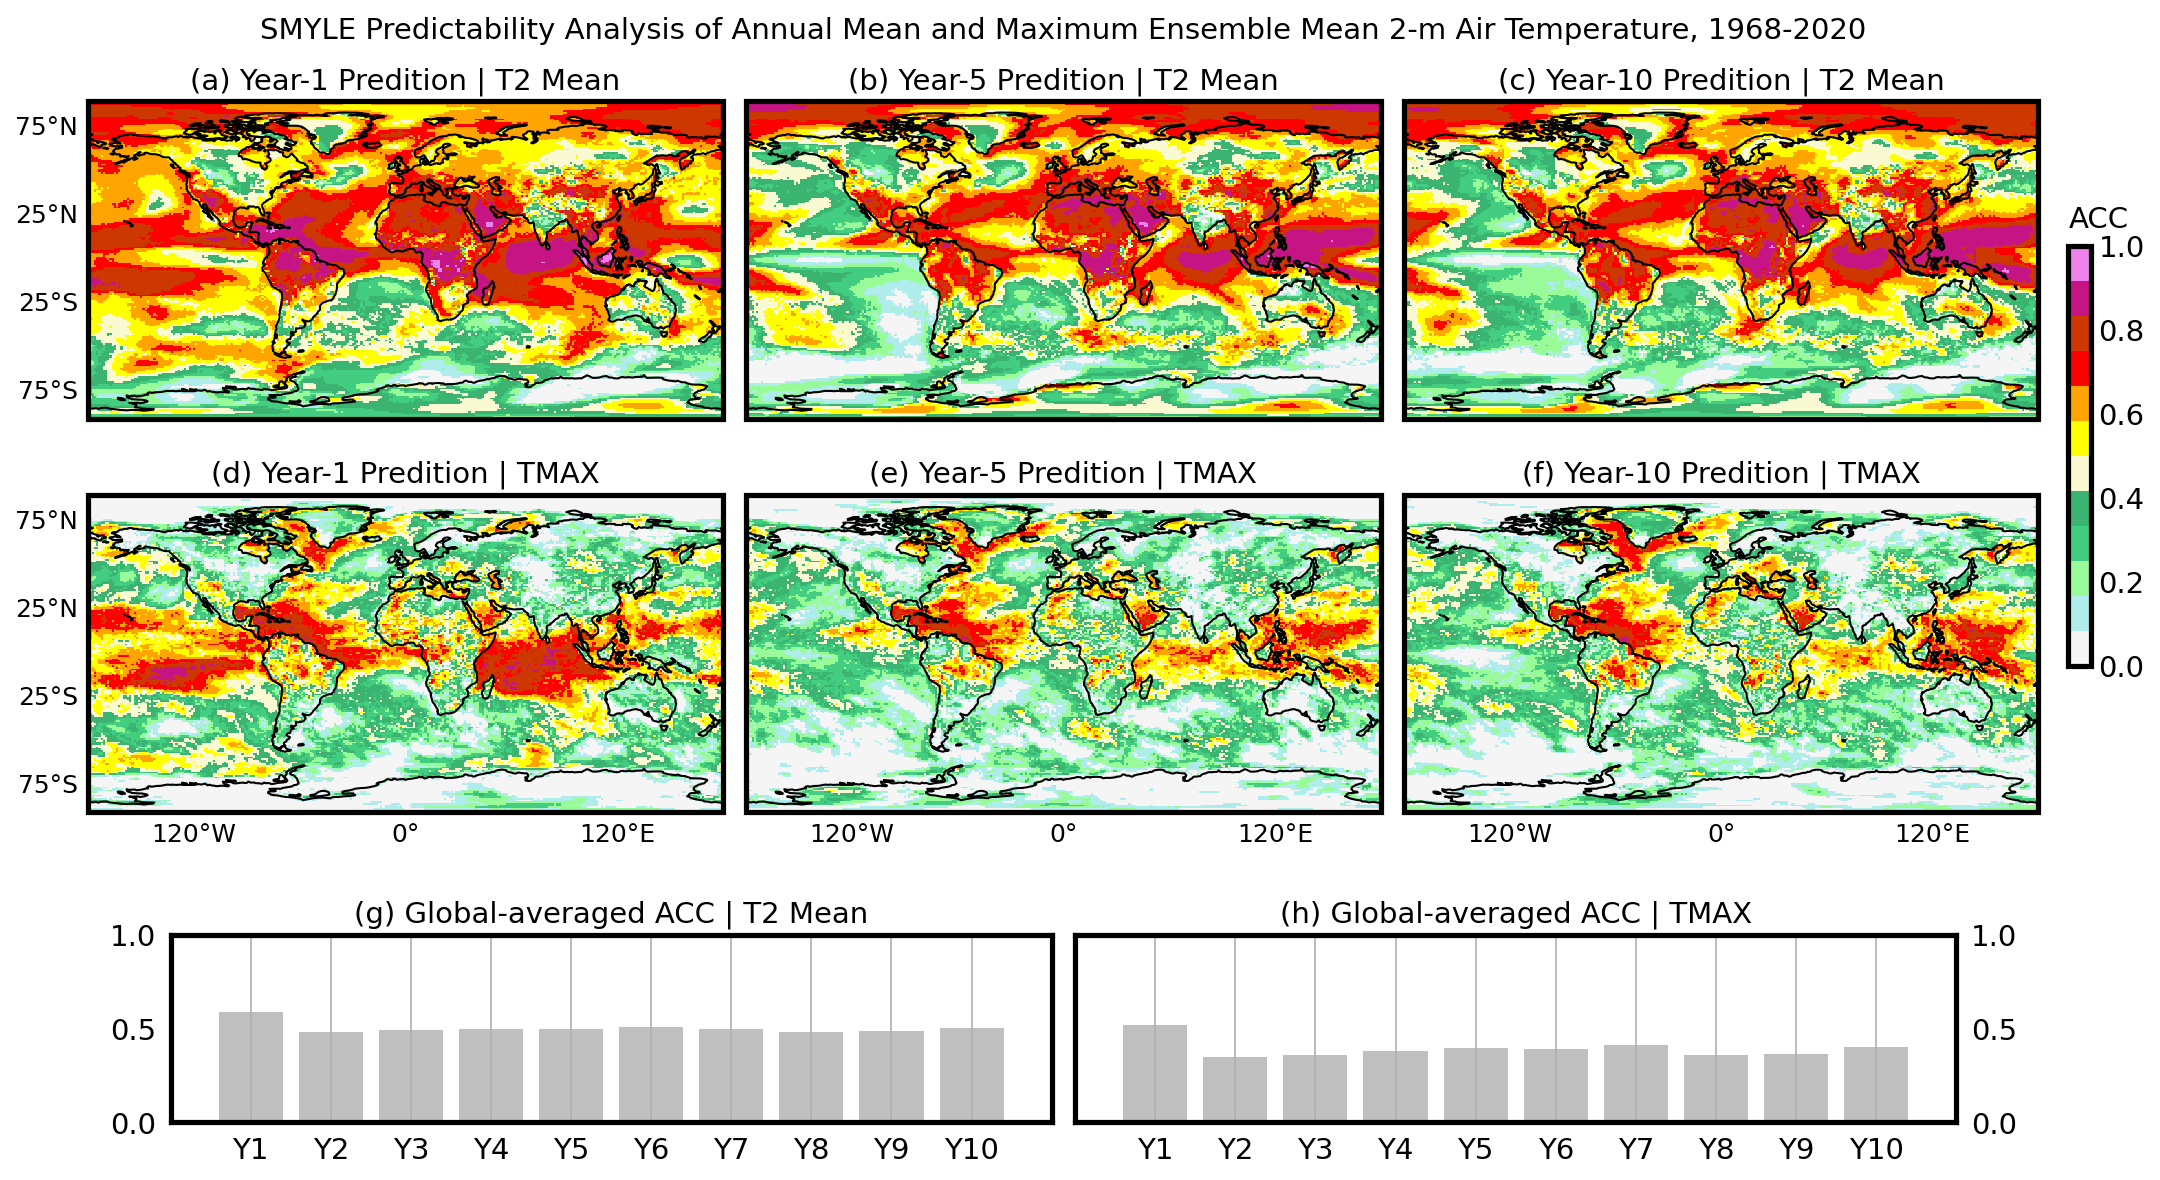

In [17]:
var_plot = ['TREFHT_mean_ACC_raw', 'TREFHTMX_max_ACC_raw']

ds_maps, ds_curves = prepare_plot_data(ds_skill, var_plot, leads_plot)
color_limits = {}
color_limits[var_plot[0]] = {'vmin': 0.0, 'vmax': 1.0}
color_limits[var_plot[1]] = {'vmin': 0.0, 'vmax': 1.0}

proj_ = ccrs.PlateCarree()
map_extent = [-180, 180, -90, 90]

fig = plt.figure(figsize=(13, 7), dpi=dpi_)
gs = gridspec.GridSpec(5, 24, height_ratios=[1, 0.05, 1, 0.25, 0.5], width_ratios=[1,]*24)

AX_ACC1 = []
AX_ACC2 = []

AX_ACC1.append(plt.subplot(gs[0, 0:8], projection=proj_))
AX_ACC1.append(plt.subplot(gs[0, 8:16], projection=proj_))
AX_ACC1.append(plt.subplot(gs[0, 16:24], projection=proj_))

AX_ACC2.append(plt.subplot(gs[2, 0:8], projection=proj_))
AX_ACC2.append(plt.subplot(gs[2, 8:16], projection=proj_))
AX_ACC2.append(plt.subplot(gs[2, 16:24], projection=proj_))

AX_maps = AX_ACC1 + AX_ACC2

AX_lines = []
AX_lines.append(plt.subplot(gs[4, 1:12]))
AX_lines.append(plt.subplot(gs[4, 12:23]))

fake_x = np.arange(10)

for ax in AX_lines:
    ax = gu.ax_decorate_box(ax)
    ax.set_xlim(-1, fake_x[-1] + 1)
    ax.set_xticks(fake_x)
    ax.set_xticklabels(['Y1', 'Y2', 'Y3', 'Y4', 'Y5', 'Y6', 'Y7', 'Y8', 'Y9', 'Y10'])
    ax.grid(axis='x')

AX_lines[0].tick_params(labelbottom=True, labelleft=True)
AX_lines[1].tick_params(labelbottom=True, labelright=True)

for i_ax, ax in enumerate(AX_maps):
    ax.set_extent(map_extent, crs=proj_)
    ax = map_gridline_opt(ax)

for i_ax, ax in enumerate([AX_ACC1[0],] + AX_ACC2):
    GL = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True, x_inline=False, y_inline=False,
        color='k', linewidth=0, linestyle=':', zorder=5
    )
    GL.top_labels = None
    GL.right_labels = None
    if i_ax == 0:
        GL.bottom_labels = None
    if i_ax > 1:
        GL.left_labels = None
        
    GL.xlabel_style = {'size': 12}
    GL.ylabel_style = {'size': 12}
    GL.xlocator = ticker.FixedLocator([-120, 0, 120])
    GL.ylocator = ticker.FixedLocator([-75, -25, 25, 75])

plt.subplots_adjust(0, 0, 1, 1, hspace=0.0, wspace=0.4)


suffix = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)', '(j)', '(k)', '(l)', '(m)', '(n)', '(o)']
suffix_count = 0

for i_lead, lead in enumerate(leads_plot):
    
    var_ = var_plot[0]
    CS1 = AX_ACC1[i_lead].pcolormesh(lon, lat, ds_maps[var_].values[i_lead], cmap=cmap_all, **color_limits[var_], transform=ccrs.PlateCarree())
    AX_ACC1[i_lead].set_title(f'{suffix[suffix_count]} Year-{lead+1} Predition | T2 Mean', fontsize=14)
    suffix_count += 1

for i_lead, lead in enumerate(leads_plot):
    
    var_ = var_plot[1]
    CS2 = AX_ACC2[i_lead].pcolormesh(lon, lat, ds_maps[var_].values[i_lead], cmap=cmap_all, **color_limits[var_], transform=ccrs.PlateCarree())
    AX_ACC2[i_lead].set_title(f'{suffix[suffix_count]} Year-{lead+1} Predition | TMAX', fontsize=14)
    suffix_count += 1
    
AX_lines[0].set_title(f'{suffix[suffix_count]} Global-averaged ACC | T2 Mean', fontsize=14)
AX_lines[1].set_title(f'{suffix[suffix_count+1]} Global-averaged ACC | TMAX', fontsize=14)

width = 0.80
fc = '0.75'

for i in range(2):
    data_ = ds_curves[var_plot[i]].values
    AX_lines[i].bar(fake_x, data_[i, :], width=width, color=fc, edgecolor="none")

AX_lines[0].set_ylim([0.0, 1.0])
AX_lines[1].set_ylim([0.0, 1.0])

ax_base1 = fig.add_axes([1.015, 0.435, 0.04, 0.4])
ax_base1.tick_params(
    axis='both', left=False, top=False, right=False, bottom=False, 
    labelleft=False, labeltop=False, labelright=False, labelbottom=False
)
cax1 = inset_axes(ax_base1, width='30%', height='100%', borderpad=0, loc=2)
CBar1 = plt.colorbar(CS1, orientation='vertical', cax=cax1) # ticks=[...]
CBar1.ax.tick_params(axis='y', labelsize=14, direction='in', length=0)
CBar1.outline.set_linewidth(2.5)
# CBar1.ax.set_ylabel('ACC', fontsize=14)
ax_base1.set_axis_off()

ax_label = fig.add_axes([1.011, 0.84, 0.04, 0.04])
ax_label.text(
    0.5, 0.5, 'ACC', 
    fontsize=14, va='center', ha='center', transform=ax_label.transAxes
)

ax_title = fig.add_axes([0.0, 1.025, 1.0, 0.03])
ax_title.text(
    0.5, 0.5, 
    'SMYLE Predictability Analysis of Annual Mean and Maximum Ensemble Mean 2-m Air Temperature, 1968-2020', 
    fontsize=14, va='center', ha='center', transform=ax_title.transAxes
)

ax_label.set_axis_off()
ax_title.set_axis_off()

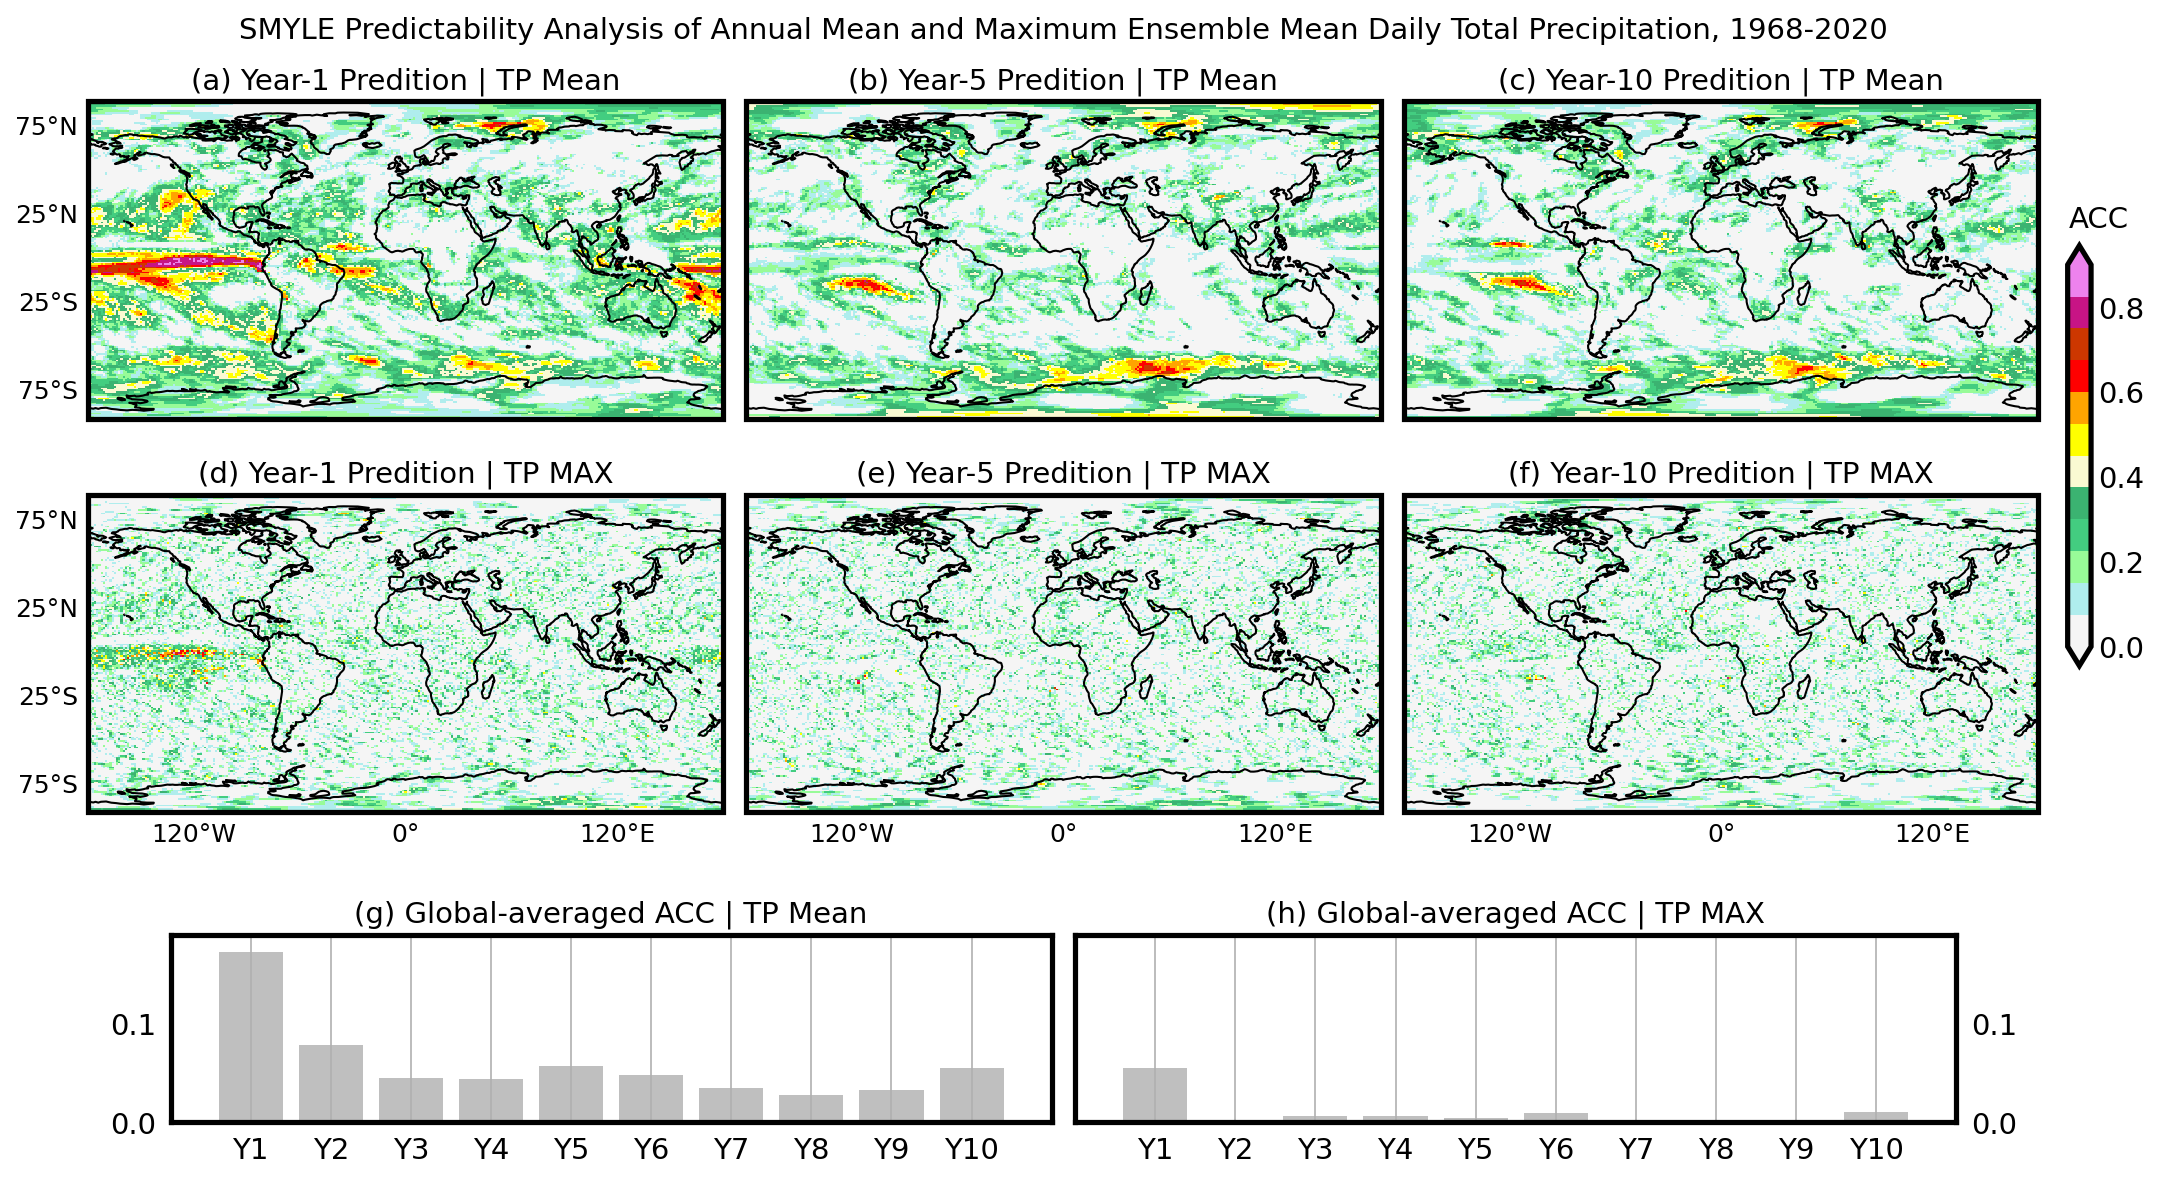

In [20]:
var_plot = ['PRECT_mean_ACC_raw', 'PRECT_max_ACC_raw']

ds_maps, ds_curves = prepare_plot_data(ds_skill, var_plot, leads_plot)
color_limits = {}
color_limits[var_plot[0]] = {'vmin': 0.0, 'vmax': 0.9}
color_limits[var_plot[1]] = {'vmin': 0.0, 'vmax': 0.9}

proj_ = ccrs.PlateCarree()
map_extent = [-180, 180, -90, 90]

fig = plt.figure(figsize=(13, 7), dpi=dpi_)
gs = gridspec.GridSpec(5, 24, height_ratios=[1, 0.05, 1, 0.25, 0.5], width_ratios=[1,]*24)

AX_ACC1 = []
AX_ACC2 = []

AX_ACC1.append(plt.subplot(gs[0, 0:8], projection=proj_))
AX_ACC1.append(plt.subplot(gs[0, 8:16], projection=proj_))
AX_ACC1.append(plt.subplot(gs[0, 16:24], projection=proj_))

AX_ACC2.append(plt.subplot(gs[2, 0:8], projection=proj_))
AX_ACC2.append(plt.subplot(gs[2, 8:16], projection=proj_))
AX_ACC2.append(plt.subplot(gs[2, 16:24], projection=proj_))

AX_maps = AX_ACC1 + AX_ACC2

AX_lines = []
AX_lines.append(plt.subplot(gs[4, 1:12]))
AX_lines.append(plt.subplot(gs[4, 12:23]))

fake_x = np.arange(10)

for ax in AX_lines:
    ax = gu.ax_decorate_box(ax)
    ax.set_xlim(-1, fake_x[-1] + 1)
    ax.set_xticks(fake_x)
    ax.set_xticklabels(['Y1', 'Y2', 'Y3', 'Y4', 'Y5', 'Y6', 'Y7', 'Y8', 'Y9', 'Y10'])
    ax.grid(axis='x')

AX_lines[0].tick_params(labelbottom=True, labelleft=True)
AX_lines[1].tick_params(labelbottom=True, labelright=True)

for i_ax, ax in enumerate(AX_maps):
    ax.set_extent(map_extent, crs=proj_)
    ax = map_gridline_opt(ax)

for i_ax, ax in enumerate([AX_ACC1[0],] + AX_ACC2):
    GL = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True, x_inline=False, y_inline=False,
        color='k', linewidth=0, linestyle=':', zorder=5
    )
    GL.top_labels = None
    GL.right_labels = None
    if i_ax == 0:
        GL.bottom_labels = None
    if i_ax > 1:
        GL.left_labels = None
        
    GL.xlabel_style = {'size': 12}
    GL.ylabel_style = {'size': 12}
    GL.xlocator = ticker.FixedLocator([-120, 0, 120])
    GL.ylocator = ticker.FixedLocator([-75, -25, 25, 75])

plt.subplots_adjust(0, 0, 1, 1, hspace=0.0, wspace=0.4)


suffix = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)', '(j)', '(k)', '(l)', '(m)', '(n)', '(o)']
suffix_count = 0

for i_lead, lead in enumerate(leads_plot):
    
    var_ = var_plot[0]
    CS1 = AX_ACC1[i_lead].pcolormesh(lon, lat, ds_maps[var_].values[i_lead], cmap=cmap_all, **color_limits[var_], transform=ccrs.PlateCarree())
    AX_ACC1[i_lead].set_title(f'{suffix[suffix_count]} Year-{lead+1} Predition | TP Mean', fontsize=14)
    suffix_count += 1

for i_lead, lead in enumerate(leads_plot):
    
    var_ = var_plot[1]
    CS2 = AX_ACC2[i_lead].pcolormesh(lon, lat, ds_maps[var_].values[i_lead], cmap=cmap_all, **color_limits[var_], transform=ccrs.PlateCarree())
    AX_ACC2[i_lead].set_title(f'{suffix[suffix_count]} Year-{lead+1} Predition | TP MAX', fontsize=14)
    suffix_count += 1
    
AX_lines[0].set_title(f'{suffix[suffix_count]} Global-averaged ACC | TP Mean', fontsize=14)
AX_lines[1].set_title(f'{suffix[suffix_count+1]} Global-averaged ACC | TP MAX', fontsize=14)

width = 0.80
fc = '0.75'

for i in range(2):
    data_ = ds_curves[var_plot[i]].values
    AX_lines[i].bar(fake_x, data_[i, :], width=width, color=fc, edgecolor="none")

AX_lines[0].set_ylim([0.0, 0.19])
AX_lines[1].set_ylim([0.0, 0.19])

ax_base1 = fig.add_axes([1.015, 0.435, 0.04, 0.4])
ax_base1.tick_params(
    axis='both', left=False, top=False, right=False, bottom=False, 
    labelleft=False, labeltop=False, labelright=False, labelbottom=False
)
cax1 = inset_axes(ax_base1, width='30%', height='100%', borderpad=0, loc=2)
CBar1 = plt.colorbar(CS1, orientation='vertical', extend='both', cax=cax1) # ticks=[...]
CBar1.ax.tick_params(axis='y', labelsize=14, direction='in', length=0)
CBar1.outline.set_linewidth(2.5)
# CBar1.ax.set_ylabel('ACC', fontsize=14)
ax_base1.set_axis_off()

ax_label = fig.add_axes([1.011, 0.84, 0.04, 0.04])
ax_label.text(
    0.5, 0.5, 'ACC', 
    fontsize=14, va='center', ha='center', transform=ax_label.transAxes
)

ax_title = fig.add_axes([0.0, 1.025, 1.0, 0.03])
ax_title.text(
    0.5, 0.5, 
    'SMYLE Predictability Analysis of Annual Mean and Maximum Ensemble Mean Daily Total Precipitation, 1968-2020', 
    fontsize=14, va='center', ha='center', transform=ax_title.transAxes
)

ax_label.set_axis_off()
ax_title.set_axis_off()